In [34]:
import zipfile
import os

zip_file_path = '/content/e88186124ec611f1.zip'
extract_dir = '/content/extracted_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"File '{zip_file_path}' unzipped to '{extract_dir}'")
print("Contents of the extracted directory:")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

File '/content/e88186124ec611f1.zip' unzipped to '/content/extracted_data'
Contents of the extracted directory:
/content/extracted_data/dataset
/content/extracted_data/dataset/test.csv
/content/extracted_data/dataset/sample_submission.csv
/content/extracted_data/dataset/train.csv


In [35]:
!pip install pygeohash catboost -q

In [36]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from catboost import CatBoostRegressor

import pygeohash as pgh

In [37]:
train = pd.read_csv("/content/extracted_data/dataset/train.csv")
test = pd.read_csv("/content/extracted_data/dataset/test.csv")
sample = pd.read_csv("/content/extracted_data/dataset/sample_submission.csv")

In [38]:
train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


## 1. Unified Feature Engineering Pipeline
To prevent data leakage and ensure uniform transformations across the board, the training and testing sets are concatenated into a single dataframe. Using an `is_train` flag allows for a clean split prior to model training, maintaining consistency in how spatial, temporal, and frequency features are encoded.

In [39]:
TARGET = "demand"

train["is_train"] = 1
test["is_train"] = 0

full = pd.concat(
    [train, test],
    axis=0,
    ignore_index=True
)

In [40]:
print(full["timestamp"].head(20))
print(full["timestamp"].dtype)

0     0:0
1     0:0
2     0:0
3     0:0
4     0:0
5     0:0
6     0:0
7     0:0
8     0:0
9     0:0
10    0:0
11    0:0
12    0:0
13    0:0
14    0:0
15    0:0
16    0:0
17    0:0
18    0:0
19    0:0
Name: timestamp, dtype: object
object


## 2. Continuous Temporal Feature Extraction
Traffic demand is highly cyclical, but raw `timestamp` strings (e.g., "14:30") cannot be natively interpreted by gradient boosting trees. Parsing these strings into discrete integers (`hour`, `minute`) and calculating an absolute `total_minutes` elapsed since midnight provides the model with a continuous linear progression of time throughout the day.

In [41]:
full["timestamp"] = full["timestamp"].astype(str)

full["hour"] = (
    full["timestamp"]
    .str.split(":")
    .str[0]
    .astype(int)
)

full["minute"] = (
    full["timestamp"]
    .str.split(":")
    .str[1]
    .astype(int)
)

full["total_minutes"] = (
    full["hour"] * 60 +
    full["minute"]
)

In [42]:
print(
    full[
        ["timestamp","hour","minute","total_minutes"]
    ].head(20)
)

   timestamp  hour  minute  total_minutes
0        0:0     0       0              0
1        0:0     0       0              0
2        0:0     0       0              0
3        0:0     0       0              0
4        0:0     0       0              0
5        0:0     0       0              0
6        0:0     0       0              0
7        0:0     0       0              0
8        0:0     0       0              0
9        0:0     0       0              0
10       0:0     0       0              0
11       0:0     0       0              0
12       0:0     0       0              0
13       0:0     0       0              0
14       0:0     0       0              0
15       0:0     0       0              0
16       0:0     0       0              0
17       0:0     0       0              0
18       0:0     0       0              0
19       0:0     0       0              0


In [43]:
print("Train Shape:", train.shape)
print("Test Shape :", test.shape)

print("\nColumns:")
print(train.columns.tolist())

print("\nTrain Head:")
display(train.head())

print("\nGeohash Samples:")
print(train["geohash"].head(10).tolist())

print("\nUnique Geohashes:")
print(train["geohash"].nunique())

print("\nUnique Timestamps:")
print(train["timestamp"].nunique())

print("\nSample Timestamps:")
print(sorted(train["timestamp"].unique())[:20])

Train Shape: (77299, 12)
Test Shape : (41778, 11)

Columns:
['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'is_train']

Train Head:


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,is_train
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN,1
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,1
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,1
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy,1
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,1



Geohash Samples:
['qp02z1', 'qp02zt', 'qp08bj', 'qp08gt', 'qp02zq', 'qp02zw', 'qp02zy', 'qp08by', 'qp08gq', 'qp08gy']

Unique Geohashes:
1249

Unique Timestamps:
96

Sample Timestamps:
['0:0', '0:15', '0:30', '0:45', '10:0', '10:15', '10:30', '10:45', '11:0', '11:15', '11:30', '11:45', '12:0', '12:15', '12:30', '12:45', '13:0', '13:15', '13:30', '13:45']


In [44]:
print("\nMissing Values:")
print(train.isnull().sum().sort_values(ascending=False))


Missing Values:
Temperature      2495
Weather           797
RoadType          600
Index               0
timestamp           0
day                 0
geohash             0
demand              0
LargeVehicles       0
NumberofLanes       0
Landmarks           0
is_train            0
dtype: int64


In [45]:
import pygeohash as pgh

print(train["geohash"].head())

for g in train["geohash"].head():
    print(g, pgh.decode(g))

0    qp02z1
1    qp02zt
2    qp08bj
3    qp08gt
4    qp02zq
Name: geohash, dtype: object
qp02z1 LatLong(latitude=-5.48492431640625, longitude=90.6646728515625)
qp02zt LatLong(latitude=-5.46295166015625, longitude=90.6866455078125)
qp08bj LatLong(latitude=-5.46295166015625, longitude=90.7086181640625)
qp08gt LatLong(latitude=-5.46295166015625, longitude=90.8624267578125)
qp02zq LatLong(latitude=-5.45745849609375, longitude=90.6756591796875)


## 3. Spatial Decoding of Geohashes
Location data is provided as alphanumeric geohash bounding boxes, which limits a tree-based algorithm's ability to interpolate spatial distances. Decoding these hashes into exact `latitude` and `longitude` coordinates plots the explicit geometry of the road network, laying the groundwork for spatial interaction mapping.

In [46]:
def decode_geo(x):
    try:
        loc = pgh.decode(x)
        return pd.Series([
            loc.latitude,
            loc.longitude
        ])
    except:
        return pd.Series([
            np.nan,
            np.nan
        ])

full[["lat", "lon"]] = full["geohash"].apply(decode_geo)

print(
    full[
        ["geohash","lat","lon"]
    ].head()
)

  geohash       lat        lon
0  qp02z1 -5.484924  90.664673
1  qp02zt -5.462952  90.686646
2  qp08bj -5.462952  90.708618
3  qp08gt -5.462952  90.862427
4  qp02zq -5.457458  90.675659


In [47]:
print(full[["lat","lon"]].describe())

                 lat            lon
count  119077.000000  119077.000000
mean       -5.349041      90.765594
std         0.058520       0.102842
min        -5.484924      90.587769
25%        -5.397034      90.675659
50%        -5.347595      90.763550
75%        -5.303650      90.851440
max        -5.237732      90.972290


In [48]:
full["lat_lon"] = full["lat"] * full["lon"]

full["lat_plus_lon"] = (
    full["lat"] + full["lon"]
)

full["lat_minus_lon"] = (
    full["lat"] - full["lon"]
)

In [49]:
from sklearn.cluster import KMeans

## 4. Synthetic Traffic Zoning via K-Means
To identify geographical hotspots and approximate origin-destination (OD) density zones, K-Means clustering is applied to the extracted coordinates. Generating multiple cluster sizes (k=10, 25, 50) builds synthetic boundaries that capture both broad, macroscopic city regions and localized, high-density micro-neighborhoods.

In [50]:
for k in [10, 25, 50]:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    full[f"geo_cluster_{k}"] = (
        km.fit_predict(
            full[["lat","lon"]]
        )
    )

In [51]:
print(
    full[
        [
            "geo_cluster_10",
            "geo_cluster_25",
            "geo_cluster_50"
        ]
    ].head()
)

   geo_cluster_10  geo_cluster_25  geo_cluster_50
0               2               9               2
1               2               9               2
2               2              16              47
3               3               8              36
4               2               9               2


In [52]:
print(train["demand"].describe())

count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64


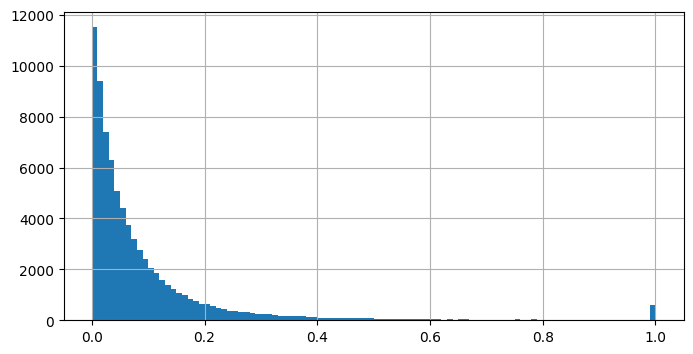

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
train["demand"].hist(bins=100)
plt.show()

In [54]:
full["Temperature"] = full["Temperature"].fillna(
    full["Temperature"].median()
)

full["RoadType"] = full["RoadType"].fillna("Unknown")
full["Weather"] = full["Weather"].fillna("Unknown")
full["Landmarks"] = full["Landmarks"].fillna("Unknown")
full["LargeVehicles"] = full["LargeVehicles"].fillna("Unknown")

In [55]:
geo_freq = train["geohash"].value_counts()

full["geohash_freq"] = (
    full["geohash"]
    .map(geo_freq)
)

In [56]:
full["day_mod_7"] = full["day"] % 7

full["is_week_start"] = (
    full["day_mod_7"] == 0
).astype(int)

full["is_week_end"] = (
    full["day_mod_7"].isin([5,6])
).astype(int)

## 5. Non-Linear Traffic Scenarios & Feature Crosses
Traffic behavior is rarely linear; the capacity and demand on a residential street shift dramatically between morning commutes and late-night hours. Engineering interaction features—such as crossing `RoadType` or `Weather` with the time of day—forces the model to evaluate highly specific environmental and temporal traffic scenarios rather than treating them as isolated variables.

In [57]:
def get_period(hour):

    if hour < 6:
        return "night"

    elif hour < 12:
        return "morning"

    elif hour < 17:
        return "afternoon"

    elif hour < 21:
        return "evening"

    return "late_night"

full["period"] = full["hour"].apply(get_period)

In [58]:
full["road_hour"] = (
    full["RoadType"].astype(str)
    + "_"
    + full["hour"].astype(str)
)

full["weather_hour"] = (
    full["Weather"].astype(str)
    + "_"
    + full["hour"].astype(str)
)

full["cluster_hour"] = (
    full["geo_cluster_25"].astype(str)
    + "_"
    + full["hour"].astype(str)
)

In [59]:
train_df = full[
    full["is_train"] == 1
].copy()

test_df = full[
    full["is_train"] == 0
].copy()

In [60]:
drop_cols = [
    "Index",
    "timestamp",
    "demand",
    "is_train"
]

features = [
    c
    for c in train_df.columns
    if c not in drop_cols
]

print("Number of Features:", len(features))

Number of Features: 27


In [61]:
X = train_df[features]
y = train_df["demand"]

X_test = test_df[features]

In [62]:
cat_cols = [
    c
    for c in X.columns
    if X[c].dtype == "object"
]

print(cat_cols)

['geohash', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'period', 'road_hour', 'weather_hour', 'cluster_hour']


In [63]:
import numpy as np

oof = np.zeros(len(X))
preds = np.zeros(len(X_test))

In [64]:
print(train_df["day"].nunique())

print(sorted(train_df["day"].unique())[:20])

print(sorted(train_df["day"].unique())[-20:])

2
[np.int64(48), np.int64(49)]
[np.int64(48), np.int64(49)]


## 6. Robust Validation & CatBoost Regressor
The pipeline utilizes `CatBoostRegressor` due to its highly optimized, native handling of categorical string features (like the geohashes and custom feature crosses), avoiding the curse of dimensionality often caused by heavy one-hot encoding. A 5-Fold Cross-Validation strategy ensures the model generalizes well to unseen traffic conditions, preventing overfitting by averaging Out-Of-Fold (OOF) predictions.

In [65]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof = np.zeros(len(X))
preds = np.zeros(len(X_test))

In [66]:
from catboost import CatBoostRegressor

for fold, (trn_idx, val_idx) in enumerate(
    kf.split(X)
):

    print(f"\n===== Fold {fold+1} =====")

    X_train = X.iloc[trn_idx]
    y_train = y.iloc[trn_idx]

    X_valid = X.iloc[val_idx]
    y_valid = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=8,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        verbose=200
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_cols,
        eval_set=(X_valid, y_valid),
        use_best_model=True
    )

    oof[val_idx] = model.predict(X_valid)

    preds += model.predict(X_test) / 5


===== Fold 1 =====
0:	learn: 0.1387659	test: 0.1387478	best: 0.1387478 (0)	total: 132ms	remaining: 6m 36s
200:	learn: 0.0394573	test: 0.0391232	best: 0.0391232 (200)	total: 23.1s	remaining: 5m 22s
400:	learn: 0.0351871	test: 0.0356683	best: 0.0356683 (400)	total: 49.2s	remaining: 5m 19s
600:	learn: 0.0330216	test: 0.0339840	best: 0.0339840 (600)	total: 1m 21s	remaining: 5m 25s
800:	learn: 0.0313610	test: 0.0328868	best: 0.0328868 (800)	total: 1m 47s	remaining: 4m 54s
1000:	learn: 0.0302016	test: 0.0322560	best: 0.0322560 (1000)	total: 2m 13s	remaining: 4m 26s
1200:	learn: 0.0293057	test: 0.0317790	best: 0.0317790 (1200)	total: 2m 43s	remaining: 4m 4s
1400:	learn: 0.0285308	test: 0.0314173	best: 0.0314173 (1400)	total: 3m 11s	remaining: 3m 38s
1600:	learn: 0.0278689	test: 0.0311402	best: 0.0311402 (1600)	total: 3m 38s	remaining: 3m 10s
1800:	learn: 0.0272984	test: 0.0309128	best: 0.0309128 (1800)	total: 4m 4s	remaining: 2m 42s
2000:	learn: 0.0267896	test: 0.0307254	best: 0.0307254 (200

In [66]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(
    mean_squared_error(y, oof)
)

print("CV RMSE =", rmse)

In [67]:
imp = pd.DataFrame({
    "feature": X.columns,
    "importance": model.get_feature_importance()
})

imp.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,importance
2,RoadType,50.971660
0,geohash,8.628157
4,LargeVehicles,7.789139
3,NumberofLanes,6.555854
19,geohash_freq,5.134099
10,total_minutes,2.953916
24,road_hour,2.095744
23,period,2.065359
15,lat_minus_lon,1.719022
14,lat_plus_lon,1.531461


In [68]:
submission = pd.DataFrame({
    "Index": test_df["Index"],
    "demand": preds
})

submission.to_csv(
    "submission.csv",
    index=False
)

print(submission.shape)
submission.head()

(41778, 2)


,Index,demand
77299,0,0.064508
77300,1,0.024531
77301,2,0.012774
77302,3,0.030096
77303,4,0.062610


In [69]:
print(submission.shape)

print(
    submission["demand"].describe()
)

print(
    submission.isnull().sum()
)

(41778, 2)
count    41778.000000
mean         0.127712
std          0.165428
min         -0.004566
25%          0.028043
50%          0.066750
75%          0.139437
max          1.097309
Name: demand, dtype: float64
Index     0
demand    0
dtype: int64


In [70]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>